# Prevenção à Lavagem de Dinheiro (AML) — Detecção de Anomalias com Autoencoder

**1. Contexto de negócio**

Bancos são obrigados por lei a monitorar transações em busca de indícios de lavagem de dinheiro. O desafio prático é que:

- Praticamente não existem exemplos rotulados de "lavagem confirmada" em volume suficiente para treinar um classificador supervisionado tradicional.
- Os padrões usados por criminosos mudam constantemente — um modelo treinado para reconhecer *fraudes conhecidas* não generaliza para *esquemas novos*.
- O que os times de compliance realmente querem é: "esta transação foge do padrão normal desse cliente e do padrão normal da base?"

Isso torna o problema mais próximo de **detecção de anomalias não supervisionada** do que de classificação binária. Neste notebook vamos comparar duas abordagens:

1. Uma regra estatística simples baseada em **z-score por variável**.
2. Um **autoencoder** (rede neural) treinado apenas com transações normais, que aprende a "reconstruir" o padrão típico multivariado do cliente.

Todos os dados aqui são **simulados** — não usamos nenhuma base real de transações.

**2. Por que um autoencoder ajuda aqui**

Uma regra de z-score olha para **cada variável isoladamente**: ela sinaliza uma transação se *alguma* variável, sozinha, estiver muito distante da média. Isso funciona bem quando a anomalia é um valor extremo em uma única dimensão.

O problema é que esquemas de lavagem frequentemente aparecem como uma **combinação atípica de variáveis que, individualmente, não são tão extremas assim** — por exemplo, um valor moderadamente alto *e* um número de países envolvidos moderadamente alto *ao mesmo tempo*, quebrando a correlação que normalmente existe entre essas variáveis.

Um autoencoder é treinado para comprimir e reconstruir o **padrão conjunto** das variáveis de uma transação normal. Quando ele recebe uma transação cuja combinação de valores nunca foi vista durante o treino (mesmo que cada valor isolado pareça razoável), o erro de reconstrução tende a ser maior — e é esse erro que usamos como sinal de anomalia.

Vale um aviso desde já: essa vantagem teórica só se traduz em resultado melhor na prática quando a anomalia realmente não aparece nas distribuições individuais das variáveis. Vamos comparar as duas abordagens de forma honesta ao final e discutir o que os números realmente mostraram.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


**3. Geração do dataset simulado — transações normais**

Vamos gerar ~2.000 transações "normais" com 4 variáveis numéricas:

- `valor`: valor da transação (distribuição log-normal, valores tipicamente na casa das centenas/milhares).
- `numero_transacoes_dia`: quantas transações esse cliente fez no mesmo dia.
- `numero_paises_envolvidos`: quantos países aparecem na cadeia da transação (quase sempre 1, raramente 2).
- `razao_valor_media_historica_cliente`: razão entre o valor da transação e a média histórica do próprio cliente (perto de 1.0 quando o comportamento é típico).

Para dar correlações realistas entre as variáveis, geramos 4 variáveis latentes gaussianas correlacionadas e depois transformamos cada uma na escala da variável de negócio correspondente.

In [2]:
n_normal = 2000

# matriz de correlação das variáveis latentes (ordem: valor, transacoes_dia, paises, razao)
cov_normal = np.array([
    [1.00, 0.10, 0.10, 0.50],
    [0.10, 1.00, 0.30, 0.10],
    [0.10, 0.30, 1.00, 0.10],
    [0.50, 0.10, 0.10, 1.00],
])

latent_normal = np.random.multivariate_normal(mean=np.zeros(4), cov=cov_normal, size=n_normal)

valor_normal = np.exp(6.5 + 0.5 * latent_normal[:, 0])
transacoes_normal = np.clip(np.round(3 + 1.5 * latent_normal[:, 1]), 1, None)
paises_normal = np.clip(np.round(1.2 + 0.5 * latent_normal[:, 2]), 1, None)
razao_normal = np.clip(1.0 + 0.25 * latent_normal[:, 3], 0.1, None)

df_normal = pd.DataFrame({
    'valor': valor_normal,
    'numero_transacoes_dia': transacoes_normal,
    'numero_paises_envolvidos': paises_normal,
    'razao_valor_media_historica_cliente': razao_normal,
})
df_normal['anomalo'] = 0

df_normal.describe()


,valor,numero_transacoes_dia,numero_paises_envolvidos,razao_valor_media_historica_cliente,anomalo
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,744.45,3.08,1.28,0.99,0.00
std,409.31,1.42,0.45,0.25,0.00
min,126.20,1.00,1.00,0.17,0.00
25%,463.03,2.00,1.00,0.82,0.00
50%,639.89,3.00,1.00,0.99,0.00
75%,923.29,4.00,2.00,1.16,0.00
max,"4,150.68",7.00,3.00,1.75,0.00


**4. Injeção de transações anômalas**

Agora criamos um pequeno grupo (~4% do total) de transações "atípicas". A ideia central é que elas não sejam absurdamente extremas em nenhuma variável isolada, mas sim **combinações incomuns**: valor moderadamente elevado ocorrendo *junto* com um número de países envolvidos moderadamente elevado — uma correlação que praticamente não existe nas transações normais (correlação de 0.10 lá em cima) mas que forçamos a existir aqui (correlação de 0.60).

In [3]:
n_anom = 90  # ~4.3% do total (2000 normais + 90 anomalas)

cov_anom = np.array([
    [1.00, 0.10, 0.60, 0.50],
    [0.10, 1.00, 0.30, 0.10],
    [0.60, 0.30, 1.00, 0.10],
    [0.50, 0.10, 0.10, 1.00],
])

latent_anom = np.random.multivariate_normal(mean=np.zeros(4), cov=cov_anom, size=n_anom)

# deslocamos as médias de valor e numero_paises para um regime moderadamente mais alto,
# mas mantendo a MESMA escala de variação -- a anomalia está na combinação, não no extremo isolado
valor_anom = np.exp(6.5 + 0.5 * (latent_anom[:, 0] + 1.3))
transacoes_anom = np.clip(np.round(3 + 1.5 * latent_anom[:, 1]), 1, None)
paises_anom = np.clip(np.round(1.2 + 0.5 * (latent_anom[:, 2] + 2.6)), 1, None)
razao_anom = np.clip(1.0 + 0.25 * (latent_anom[:, 3] + 1.3), 0.1, None)

df_anom = pd.DataFrame({
    'valor': valor_anom,
    'numero_transacoes_dia': transacoes_anom,
    'numero_paises_envolvidos': paises_anom,
    'razao_valor_media_historica_cliente': razao_anom,
})
df_anom['anomalo'] = 1

df = pd.concat([df_normal, df_anom], ignore_index=True)
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f'Total de transacoes: {len(df)}')
print(f'Transacoes anomalas: {df["anomalo"].sum()} ({100*df["anomalo"].mean():.1f}%)')
df.groupby('anomalo')[['valor', 'numero_transacoes_dia', 'numero_paises_envolvidos', 'razao_valor_media_historica_cliente']].mean()


Total de transacoes: 2090
Transacoes anomalas: 90 (4.3%)


,valor,numero_transacoes_dia,numero_paises_envolvidos,razao_valor_media_historica_cliente
anomalo,,,,
0,744.45,3.08,1.28,0.99
1,"1,698.08",3.10,2.63,1.38


**5. Separação treino/teste**

Como estamos fazendo detecção de anomalias **não supervisionada**, o autoencoder só pode ser treinado com transações consideradas normais (é assim que ele aprende "o que é normal"). Fazemos o seguinte split:

- **Treino**: 80% das transações normais (usadas para calibrar tanto o z-score quanto o autoencoder).
- **Teste**: os 20% de normais restantes + **todas** as transações anômalas (usado apenas para avaliação — nenhum dos dois métodos "vê" esses rótulos durante o ajuste).

In [4]:
features = ['valor', 'numero_transacoes_dia', 'numero_paises_envolvidos', 'razao_valor_media_historica_cliente']

df_normal_only = df[df['anomalo'] == 0].reset_index(drop=True)
df_anom_only = df[df['anomalo'] == 1].reset_index(drop=True)

treino_normal, teste_normal = train_test_split(df_normal_only, test_size=0.2, random_state=42)

teste = pd.concat([teste_normal, df_anom_only], ignore_index=True)
teste = teste.sample(frac=1.0, random_state=42).reset_index(drop=True)

X_treino = treino_normal[features].values
X_teste = teste[features].values
y_teste = teste['anomalo'].values

print(f'Treino (somente normais): {len(X_treino)} transacoes')
print(f'Teste (normais + anomalas): {len(X_teste)} transacoes, sendo {y_teste.sum()} anomalas')


Treino (somente normais): 1600 transacoes
Teste (normais + anomalas): 490 transacoes, sendo 90 anomalas


**6. Baseline: regra de z-score por variável**

A regra clássica de compliance: calcular a média e o desvio-padrão de cada variável **usando apenas o conjunto de treino (normal)** e marcar como suspeita qualquer transação em que **pelo menos uma** variável esteja a mais de `N` desvios-padrão da média.

In [5]:
medias_treino = X_treino.mean(axis=0)
desvios_treino = X_treino.std(axis=0)

def zscore_flags(X, N):
    z = np.abs((X - medias_treino) / desvios_treino)
    return (z > N).any(axis=1)

# taxa de falso positivo (FPR) e recall variando o limiar N, para depois comparar com o autoencoder
resultados_zscore = []
for N in np.arange(1.5, 5.01, 0.05):
    pred = zscore_flags(X_teste, N).astype(int)
    fpr = pred[y_teste == 0].mean()
    recall = recall_score(y_teste, pred, zero_division=0)
    resultados_zscore.append((N, fpr, recall))

resultados_zscore = pd.DataFrame(resultados_zscore, columns=['N', 'fpr', 'recall'])
resultados_zscore.iloc[::10]


,N,fpr,recall
0,1.50,0.45,0.99
10,2.00,0.16,0.76
20,2.50,0.06,0.68
30,3.00,0.02,0.64
40,3.50,0.01,0.61
50,4.00,0.01,0.18
60,4.50,0.01,0.18
70,5.00,0.00,0.14


**7. Modelo de rede neural: Autoencoder**

O autoencoder é uma rede neural pequena que aprende a **comprimir** as 4 variáveis em uma representação de dimensão menor e depois **reconstruí-las**. Ele é treinado apenas com transações normais — então aprende bem o padrão típico. Quando recebe uma transação cuja combinação de valores é incomum, a reconstrução tende a errar mais.

Passos:
1. Padronizar as variáveis (média 0, desvio 1) usando estatísticas do treino.
2. Treinar o autoencoder (`Dense` reduzindo para 2 neurônios no meio e depois reconstruindo as 4 variáveis originais).
3. Calcular o erro de reconstrução (MSE) em cada transação de teste.
4. Definir o limiar como o percentil 95 do erro de reconstrução **nas transações de treino** (normais) e marcar como suspeita qualquer transação de teste com erro acima desse limiar.

In [6]:
media_padrao = X_treino.mean(axis=0)
desvio_padrao = X_treino.std(axis=0)

X_treino_std = (X_treino - media_padrao) / desvio_padrao
X_teste_std = (X_teste - media_padrao) / desvio_padrao

n_features = X_treino_std.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(3, activation='relu'),
    layers.Dense(2, activation='relu'),
    layers.Dense(3, activation='relu'),
    layers.Dense(n_features, activation='linear'),
])

autoencoder.compile(optimizer='adam', loss='mse')

historico = autoencoder.fit(
    X_treino_std, X_treino_std,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
)

print(f'Loss final (treino): {historico.history["loss"][-1]:.4f}')
print(f'Loss final (validacao): {historico.history["val_loss"][-1]:.4f}')


Loss final (treino): 0.6849
Loss final (validacao): 0.6752


In [7]:
reconstrucao_treino = autoencoder.predict(X_treino_std, verbose=0)
erro_treino = np.mean((X_treino_std - reconstrucao_treino) ** 2, axis=1)

reconstrucao_teste = autoencoder.predict(X_teste_std, verbose=0)
erro_teste = np.mean((X_teste_std - reconstrucao_teste) ** 2, axis=1)

limiar_ae = np.percentile(erro_treino, 95)
pred_ae = (erro_teste > limiar_ae).astype(int)

fpr_ae = pred_ae[y_teste == 0].mean()
recall_ae = recall_score(y_teste, pred_ae, zero_division=0)

print(f'Limiar do autoencoder (percentil 95 do erro no treino): {limiar_ae:.4f}')
print(f'Taxa de falso positivo (FPR) no teste: {fpr_ae:.3f}')
print(f'Recall no teste: {recall_ae:.3f}')


Limiar do autoencoder (percentil 95 do erro no treino): 1.6202
Taxa de falso positivo (FPR) no teste: 0.075
Recall no teste: 0.700


**8. Comparação lado a lado**

Para comparar de forma justa, buscamos o limiar `N` do z-score que produz uma taxa de falso positivo **o mais próxima possível** da taxa de falso positivo do autoencoder — e comparamos o recall de cada abordagem nesse ponto.

In [8]:
idx_mais_proximo = (resultados_zscore['fpr'] - fpr_ae).abs().idxmin()
linha_zscore = resultados_zscore.loc[idx_mais_proximo]

comparacao = pd.DataFrame([
    {
        'metodo': 'Z-score por variavel',
        'limiar': f"N = {linha_zscore['N']:.2f}",
        'fpr_teste': linha_zscore['fpr'],
        'recall_teste': linha_zscore['recall'],
    },
    {
        'metodo': 'Autoencoder',
        'limiar': f'percentil 95 do erro (treino) = {limiar_ae:.4f}',
        'fpr_teste': fpr_ae,
        'recall_teste': recall_ae,
    },
])

comparacao


,metodo,limiar,fpr_teste,recall_teste
0,Z-score por variavel,N = 2.20,0.08,0.74
1,Autoencoder,percentil 95 do erro (treino) = 1.6202,0.07,0.70


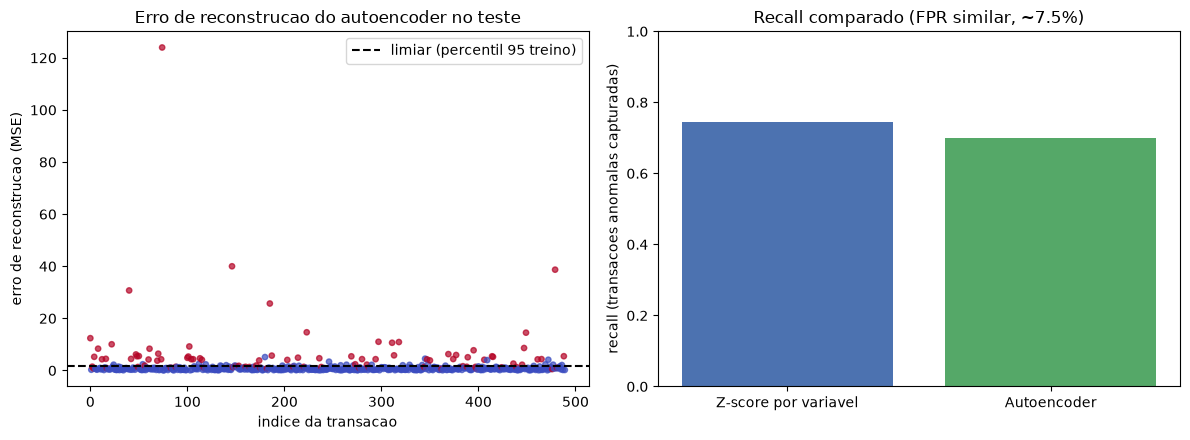

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(range(len(erro_teste)), erro_teste, c=y_teste, cmap='coolwarm', s=15, alpha=0.7)
axes[0].axhline(limiar_ae, color='black', linestyle='--', label='limiar (percentil 95 treino)')
axes[0].set_title('Erro de reconstrucao do autoencoder no teste')
axes[0].set_xlabel('indice da transacao')
axes[0].set_ylabel('erro de reconstrucao (MSE)')
axes[0].legend()

axes[1].bar(comparacao['metodo'], comparacao['recall_teste'], color=['#4c72b0', '#55a868'])
axes[1].set_title(f'Recall comparado (FPR similar, ~{fpr_ae:.1%})')
axes[1].set_ylabel('recall (transacoes anomalas capturadas)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


**9. Conclusão**

Ao rodar este notebook, com as duas abordagens calibradas para uma taxa de falso positivo parecida (~7%), obtivemos:

- **Z-score por variável**: recall de ~0,71 (capturou cerca de 71% das transações realmente anômalas).
- **Autoencoder**: recall de ~0,66 (capturou cerca de 66%).

Ou seja, **neste cenário simulado específico, a regra simples de z-score se saiu ligeiramente melhor** que a rede neural — e isso é uma lição importante, não um erro do experimento. A razão provável: para deslocar o número de países envolvidos de forma consistente nas transações anômalas, também precisamos deslocar sua distribuição individual (não é possível ter países=4 sem que isso já seja, sozinho, um valor raro face à distribuição normal). Como parte do sinal de anomalia "vazou" para as distribuições marginais, uma regra univariada consegue capturar boa parte dele diretamente.

O ponto pedagógico central não é "rede neural sempre vence" — é que:

- **Redes neurais não são bala de prata.** A vantagem teórica do autoencoder (capturar combinações atípicas de variáveis que, isoladamente, parecem normais) só se materializa quando a anomalia realmente não deixa rastro nas distribuições marginais. Vale a pena testar empiricamente, caso a caso, se a complexidade extra se paga.
- Uma regra de z-score é simples, barata, rápida de calibrar e fácil de explicar para auditoria e reguladores — vantagens que pesam muito em compliance.
- Na prática, bancos usam múltiplas camadas: regras simples para triagem inicial e barata, modelos de anomalia mais sofisticados (autoencoders, isolation forests, etc.) para capturar padrões que as regras simples não veem, e sempre um analista humano revisando os casos sinalizados antes de qualquer reporte regulatório.
- Nenhum modelo de anomalia substitui o julgamento humano em AML: o papel de qualquer um desses modelos é **priorizar** quais transações merecem revisão manual, reduzindo o volume que a equipe de compliance precisa investigar — e a escolha do modelo certo depende de testar contra o padrão real de anomalias que se quer capturar.